# Predict Titanic's passengers survival

<img src="./titanic2.png" width="800" height="200" alt="Imagem do Titanic em falta!">



- Survived: Wheather the person Survived or not.

- Pclass: Passanger class indicates the class of that person aboard the ship.

- SibSp: Shows the number of Sibling/Spouces they had.

- Parch: Parch indicates Parents with children

- TIcket: Ticket name/Number.

- Fare: How much the Passenger paid.

- Cabin: Cabin name of that Passenger.

- Embarked: Point of Embarkation where C means Cherbourg, Q means Queenstown, S means Southampton.


## Libraries Import

In [86]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns


In [87]:
d_train=pd.read_csv("../datasets/titanic_train.csv")
d_test=pd.read_csv("../datasets/titanic_test.csv")
d_pred=pd.read_csv("../datasets/titanic_test_results.csv")

In [88]:
d_train.columns, d_test.columns, d_pred.columns

(Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
        'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
       dtype='object'),
 Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
        'Ticket', 'Fare', 'Cabin', 'Embarked'],
       dtype='object'),
 Index(['PassengerId', 'Survived'], dtype='object'))

In [89]:
df=d_train

## EDA

In [90]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [92]:
# use describe on non-numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [93]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Incomplete data
- Age, Cabin, Embarked

### strategy
- age - we will fill missing values with the average age of each class
- cabin - too many missing values. Besides not holding relevant information, filling the blanks would introduce too much errors. Solution: column drop
- name - although we have the names, we'll drop the column as it doesn't bring added value
- embarked - as the "S" class is predominant, we could fill the blanks with that value. However as there are only two missing values (see above), in a pedagogic strategy, we'll discard those lines. 

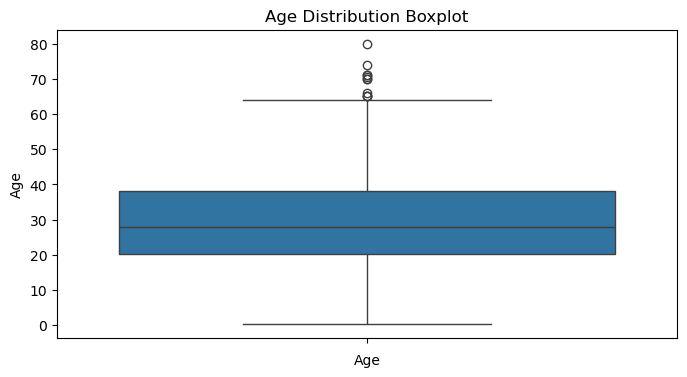

In [94]:
# the age columns has a very large spectrum but the quartiles are very close to each other
# Let's create a Boxplot to check Age distribution

plt.figure(figsize=(8, 4))
sns.boxplot(data=df["Age"])
plt.title("Age Distribution Boxplot")
plt.xlabel("Age")
plt.show()

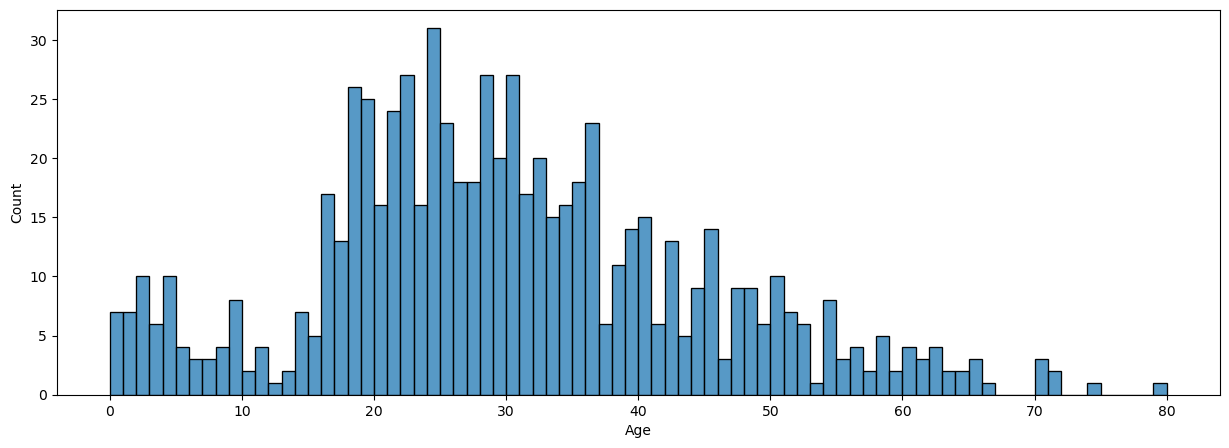

In [95]:
# The minimum age is 0.17 and the maximum is 80. How are the ages of the passengers distributed?

plt.figure(figsize = [15,5])
sns.histplot(df['Age'].dropna(),bins = range(0,81,1))
plt.show()

In [96]:
# 25% of the tickets cost less than 8. However, there are ticket(s) priced at 512. What do we know about these passenger(s)?

df[df["Fare"]>500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


<Axes: ylabel='Fare'>

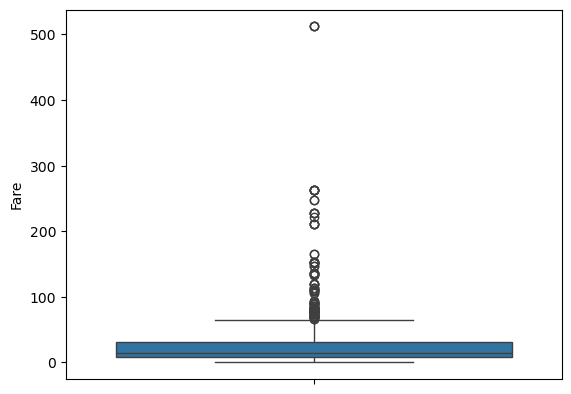

In [97]:
# Let's check for outliers in the Fare column
sns.boxplot(data=df['Fare'])


- nr of unique (nunique()) vs unique values (unique())

In [98]:
# how many different values there are in each column?
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [99]:
# what are the 3 different values in the Embarked column?
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [100]:
# How many passengers embarked at each of the 3 ports?
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [101]:
# How many survivors by port of embarkment?

df[df['Survived']==1].Embarked.value_counts()

Embarked
S    217
C     93
Q     30
Name: count, dtype: int64

In [102]:
# What is the average age of women and men?
print(f'Average age of women: {df[df.Sex=="female"].Age.mean():.1f}')
print(f'Average age of men:   {df[df.Sex=="male"].Age.mean():.1f}')

Average age of women: 27.9
Average age of men:   30.7


In [103]:
# There are many missing values in the Cabin column?
df.Cabin.isnull().value_counts()

Cabin
True     687
False    204
Name: count, dtype: int64

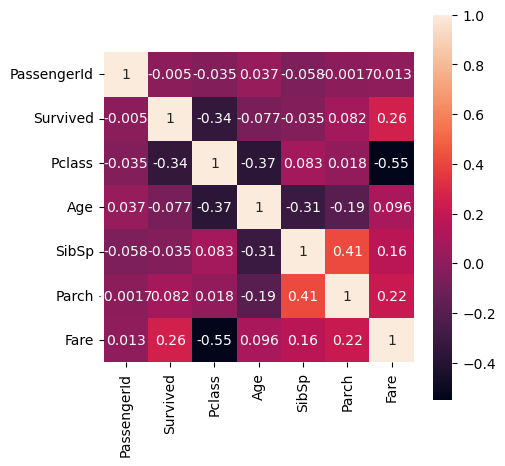

In [104]:
# Checking correlations
# heatmap with the data from the correlation matrix
f, ax = plt.subplots(figsize = [5,5])
sns.heatmap(df.corr(numeric_only = True), square = True,annot = True)
plt.show()

## Pre-processing

- Name doesn't add information. Can be discarded
- it's a small dataset and we need to increase the possibilities of capturing all alternatives
- avoid out-of-bounds data, new classes, etc if pre-processing only Training
- In real problems, when we already have the system in production and new data arrives, these also have to go through the pre-proc pipeline


In [105]:
df=df.drop(["Name","Cabin","PassengerId"],axis=1)

d_test=d_test.drop(["Name","Cabin","PassengerId"],axis=1)

In [106]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [107]:
# this function (dropna) eliminates the rows with null values in the specified column(s). In all colummns if none is specified
df=df.dropna(subset=["Embarked"])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [108]:
# What is the average of the numeric attributes for each class?

df[['Pclass','Age','Fare']].groupby("Pclass").mean()

,Age,Fare
Pclass,,
1,38.105543,84.193516
2,29.877630,20.662183
3,25.140620,13.675550


In [109]:
# We can use the average age by class to fill the missing values in the Age column.

#df['Age']=df['Age'].fillna((df['Age'].mean()))

df.loc[(df.Pclass==1) & (df.Age.isna()),"Age"]=39.1
df.loc[(df.Pclass==2) & (df.Age.isna()),"Age"]=29.5
df.loc[(df.Pclass==3) & (df.Age.isna()),"Age"]=24.8

In [110]:
df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
5,0,3,male,24.8,0,0,330877,8.4583,Q
6,0,1,male,54.0,0,0,17463,51.8625,S
7,0,3,male,2.0,3,1,349909,21.0750,S
8,1,3,female,27.0,0,2,347742,11.1333,S
9,1,2,female,14.0,1,0,237736,30.0708,C


In [111]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

### Encoding

In [112]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Embarked     object
dtype: object

___ As features do tipo Object têm que ser convertidas para tipos numéricos ___  
Sex e Embarked serão codificados  
Ticket pode ser eliminado

In [113]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [114]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [115]:
#c=['Sex', 'Ticket', 'Embarked']

columns_to_encode=['Sex', 'Embarked']
# encoding done on columns_to_encode, keeping the rest of the dataframe 
encoded_data = encoder.fit_transform(df[columns_to_encode])
encoder.categories_


[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [116]:
# encode the test data with the same encoder
encoded_test_data = encoder.transform(d_test[columns_to_encode])    


In [117]:
encoded_data

array([[0., 1., 0., 0., 1.],
       [1., 0., 1., 0., 0.],
       [1., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 1.],
       [0., 1., 1., 0., 0.],
       [0., 1., 0., 1., 0.]], shape=(889, 5))

In [118]:
feature_names = encoder.get_feature_names_out(columns_to_encode)

In [119]:
feature_names

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype=object)

In [120]:
# Create a DataFrame from the encoded data
encoded_df = pd.DataFrame(encoded_data, columns=feature_names)
encoded_df



,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
884,0.0,1.0,0.0,0.0,1.0
885,1.0,0.0,0.0,0.0,1.0
886,1.0,0.0,0.0,0.0,1.0
887,0.0,1.0,1.0,0.0,0.0


In [121]:
#create a dataframe with the encoded test data
encoded_test_df = pd.DataFrame(encoded_test_data, columns=feature_names)
encoded_test_df

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...
413,0.0,1.0,0.0,0.0,1.0
414,1.0,0.0,1.0,0.0,0.0
415,0.0,1.0,0.0,0.0,1.0
416,0.0,1.0,0.0,0.0,1.0


In [122]:
print(df[df.isna().any(axis=1)])

Empty DataFrame
Columns: [Survived, Pclass, Sex, Age, SibSp, Parch, Ticket, Fare, Embarked]
Index: []


In [123]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,24.8,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [124]:
encoded_df

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
884,0.0,1.0,0.0,0.0,1.0
885,1.0,0.0,0.0,0.0,1.0
886,1.0,0.0,0.0,0.0,1.0
887,0.0,1.0,1.0,0.0,0.0


In [125]:
df=df.drop("Ticket",axis=1)
# repetir para o df de teste
d_test=d_test.drop("Ticket",axis=1)

In [126]:
df = df.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

d_test = d_test.reset_index(drop=True)
encoded_test_df = encoded_test_df.reset_index(drop=True)

In [127]:
# Combine the encoded data with the original DataFrame
df2 = pd.concat([df, encoded_df], axis=1)
df=df2.drop(columns_to_encode,axis=1)

d_test2 = pd.concat([d_test, encoded_test_df], axis=1)
d_test=d_test2.drop(columns_to_encode,axis=1)

In [128]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
884,0,2,27.0,0,0,13.0000,0.0,1.0,0.0,0.0,1.0
885,1,1,19.0,0,0,30.0000,1.0,0.0,0.0,0.0,1.0
886,0,3,24.8,1,2,23.4500,1.0,0.0,0.0,0.0,1.0
887,1,1,26.0,0,0,30.0000,0.0,1.0,1.0,0.0,0.0


## Train

### Random Forest

In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import confusion_matrix, accuracy_score

In [130]:
X_train = df.drop(['Survived'], axis=1)
y_train = df['Survived']

X_test = d_test
y_test = d_pred.Survived



In [131]:
X_train.isnull().sum()

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [132]:
rf = RandomForestClassifier(random_state=24)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [133]:
rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8397129186602871


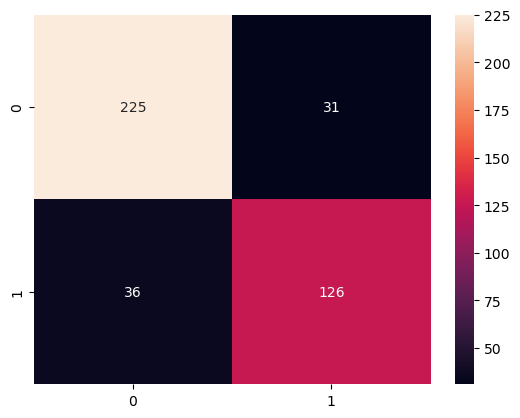

In [134]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='g')
plt.show()

## Optimizing the Random Forest model with GridSearchCV

In [135]:
# Get all the parameters
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 24,
 'verbose': 0,
 'warm_start': False}

In [136]:
%%time
# parameters for RF search

rf_params={ 'max_depth':[None, 3, 5, 10],
           'max_features': ['sqrt', 'log2', None, 3, 10],
           'min_samples_split': [2,5,10],
           'n_estimators': [10,50,100,150]           
}

rf_gs = GridSearchCV(RandomForestClassifier(random_state=24), 
                           rf_params,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)

rf_gs.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
CPU times: total: 4.14 s
Wall time: 36.1 s


,estimator,RandomForestC...ndom_state=24)
,param_grid,"{'max_depth': [None, 3, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [10, 50, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [137]:
rf_gs.best_params_

{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_split': 2,
 'n_estimators': 100}

In [138]:
rf2 = RandomForestClassifier(
    max_depth         =rf_gs.best_params_['max_depth'],
    max_features      =rf_gs.best_params_['max_features'],
    min_samples_split = rf_gs.best_params_['min_samples_split'],
    n_estimators      =rf_gs.best_params_['n_estimators'],
    random_state=24
)

rf2.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
rf_pred2=rf2.predict(X_test)
accuracy_score(y_test, rf_pred2)

0.868421052631579

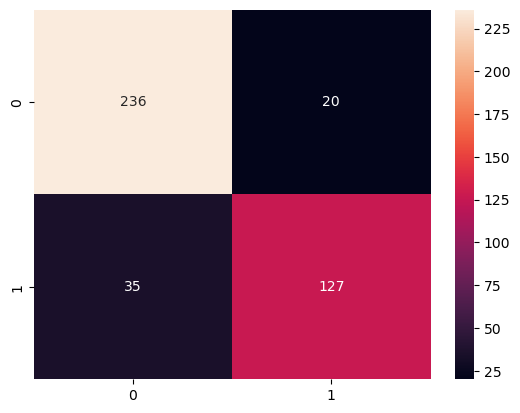

In [140]:
sns.heatmap(confusion_matrix(y_test, rf_pred2), annot=True, fmt='g')
plt.show()